In [1]:
!pip install kagglehub

In [2]:
import kagglehub
path = kagglehub.dataset_download("janmejaybhoi/cotton-disease-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\anujr\.cache\kagglehub\datasets\janmejaybhoi\cotton-disease-dataset\versions\1


In [3]:
import os
print(os.listdir(path))

['Cotton Disease']


In [4]:
base_path = os.path.join(path, "Cotton Disease")
print(os.listdir(base_path))

['test', 'train', 'val']


In [5]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import os

transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

# Correct base path
base_path = os.path.join(path, "Cotton Disease")

train_path = os.path.join(base_path, "train")
test_path  = os.path.join(base_path, "test")
valid_path = os.path.join(base_path, "val")

trainset = ImageFolder(root=train_path, transform=transform)
testset  = ImageFolder(root=test_path, transform=transform)
validset = ImageFolder(root=valid_path, transform=transform)

trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader  = DataLoader(testset, batch_size=32, shuffle=False)
validloader = DataLoader(validset, batch_size=32, shuffle=False)

print("Classes:", trainset.classes)

Classes: ['diseased cotton leaf', 'diseased cotton plant', 'fresh cotton leaf', 'fresh cotton plant']


In [6]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN,self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )

        self.fc_layer = nn.Sequential(
            nn.Linear(4*4*128,256),
            nn.ReLU(),
            nn.Linear(256,num_classes)
        )

    def forward(self,x):
        x = self.conv_layers(x)
        x = torch.flatten(x,1)
        x = self.fc_layer(x)
        return x

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN(num_classes=len(trainset.classes)).to(device)

In [8]:
# loss and optimizer
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
# Training loop
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 61.9734
Epoch 2, Loss: 38.5966
Epoch 3, Loss: 28.8664
Epoch 4, Loss: 22.6610
Epoch 5, Loss: 18.6306
Epoch 6, Loss: 15.3185
Epoch 7, Loss: 13.0488
Epoch 8, Loss: 10.5208
Epoch 9, Loss: 7.0107
Epoch 10, Loss: 6.9598


In [10]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 90.56603773584905


In [11]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[23  0  1  1]
 [ 1 27  0  0]
 [ 0  1 25  0]
 [ 0  6  0 21]]


In [12]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=trainset.classes))

                       precision    recall  f1-score   support

 diseased cotton leaf       0.96      0.92      0.94        25
diseased cotton plant       0.79      0.96      0.87        28
    fresh cotton leaf       0.96      0.96      0.96        26
   fresh cotton plant       0.95      0.78      0.86        27

             accuracy                           0.91       106
            macro avg       0.92      0.91      0.91       106
         weighted avg       0.91      0.91      0.91       106



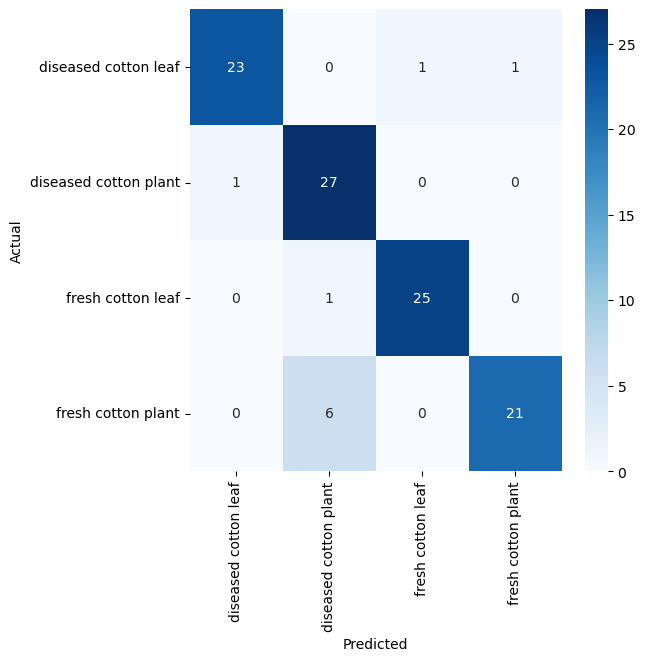

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=trainset.classes,
            yticklabels=trainset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
for i in range(len(all_preds)):
    if all_preds[i] != all_labels[i]:
        print("Actual:", all_labels[i], "Pred:", all_preds[i])
        break

Actual: 0 Pred: 3


# Using Rasnet 50

In [15]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),   # 🔥 MUST
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [16]:
trainset = ImageFolder(root=train_path, transform=transform)
testset  = ImageFolder(root=test_path, transform=transform)

trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader  = DataLoader(testset, batch_size=32, shuffle=False)

In [17]:
# load rassnet
from torchvision import models
import torch.nn as nn

model = models.resnet50(pretrained=True)

C:\Users\anujr\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\anujr\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [18]:
from torchvision import models
from torchvision.models import ResNet50_Weights

model = models.resnet50(weights=ResNet50_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\anujr/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:15<00:00, 6.52MB/s]


In [19]:
# freezing layer
for param in model.parameters():
    param.requires_grad = False

In [20]:
# change the last layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(trainset.classes))

In [21]:
# loss optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

In [22]:
# training loop
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 47.0673
Epoch 2, Loss: 24.3928
Epoch 3, Loss: 18.4827
Epoch 4, Loss: 15.2133
Epoch 5, Loss: 13.4118
Epoch 6, Loss: 11.4785
Epoch 7, Loss: 11.0576
Epoch 8, Loss: 10.7924
Epoch 9, Loss: 10.3234
Epoch 10, Loss: 9.6261


In [24]:
# accuracy check
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("ResNet Accuracy:", 100 * correct / total)

ResNet Accuracy: 96.22641509433963


In [25]:
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=trainset.classes))

                       precision    recall  f1-score   support

 diseased cotton leaf       0.96      0.92      0.94        25
diseased cotton plant       0.79      0.96      0.87        28
    fresh cotton leaf       0.96      0.96      0.96        26
   fresh cotton plant       0.95      0.78      0.86        27

             accuracy                           0.91       106
            macro avg       0.92      0.91      0.91       106
         weighted avg       0.91      0.91      0.91       106



In [26]:
torch.save(model.state_dict(), "resnet50_model.pth")

In [1]:
import os
os.getcwd()

'C:\\Users\\anujr'